# Dataset Link



https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("./loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.shape

(4269, 13)

In [4]:
df.columns.to_list()

['loan_id',
 ' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

In [5]:
df.columns = df.columns.str.strip()
df.columns.tolist()

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [7]:
df.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_id,4269.0,NaN,NaN,NaN,2135.0,1232.498479,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,NaN,NaN,NaN,2.498712,1.69591,0.0,1.0,3.0,4.0,5.0
education,4269,2,Graduate,2144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,4269,2,Yes,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_annum,4269.0,NaN,NaN,NaN,5059123.916608,2806839.831818,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,NaN,NaN,NaN,15133450.456781,9043362.984843,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,NaN,NaN,NaN,10.900445,5.709187,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,NaN,NaN,NaN,599.936051,172.430401,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,NaN,NaN,NaN,7472616.537831,6503636.587664,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,NaN,NaN,NaN,4973155.305692,4388966.089638,0.0,1300000.0,3700000.0,7600000.0,19400000.0


# EDA

In [8]:
target_col = "loan_status"

Using Target Columns :  loan_status


loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

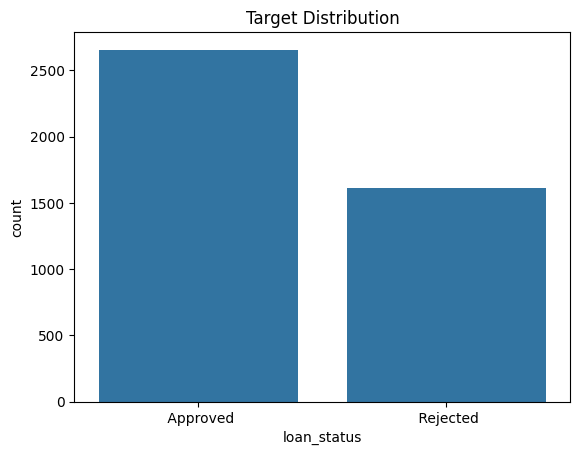

In [9]:
print("Using Target Columns : ", target_col)
display(df[target_col].value_counts(dropna = False))
sns.countplot(x = target_col, data = df)
plt.title("Target Distribution")
plt.show()

In [10]:
df = df.drop(columns = ["loan_id"], errors = "ignore")
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [11]:
df_clf = df.dropna(subset = [target_col]).copy()

In [12]:
X = df_clf.drop(columns = [target_col])
y = df_clf[target_col]

In [13]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [14]:
y.head()

0     Approved
1     Rejected
2     Rejected
3     Rejected
4     Rejected
Name: loan_status, dtype: object

# Feature Type

In [15]:
cat_cols = X.select_dtypes(include = ["object", "category"]).columns.to_list()
num_cols = X.select_dtypes(include = [np.number]).columns.to_list()

In [16]:
print("Categorical Columns : ", cat_cols)
print("Numerical Columns : ", num_cols)

Categorical Columns :  ['education', 'self_employed']
Numerical Columns :  ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


# Preprocessing Pipeline

In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [18]:
num_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = "median")),
    ('scaler', StandardScaler())
])

In [19]:
cat_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = "most_frequent")),
    ('encoder', OneHotEncoder(handle_unknown = "ignore"))
])

In [20]:
preprocessor = ColumnTransformer(transformers = [
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder = 'drop')

In [21]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


# Satge - 1 Classification Baseline

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [23]:
y.unique()

array([' Approved', ' Rejected'], dtype=object)

In [24]:
y = df_clf[target_col].astype(str).str.strip().str.lower()
y.unique()

array(['approved', 'rejected'], dtype=object)

In [25]:
y = (y == 'approved').astype(int)
y.unique()

array([1, 0])

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
print("Train Size : ", X_train.shape)
print("Test Size : ", X_test.shape)

Train Size :  (3415, 11)
Test Size :  (854, 11)


# FIt RF Basline Pipeline

In [27]:
rf_clf_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('rf_cls', RandomForestClassifier())
])

In [28]:
from sklearn.model_selection import GridSearchCV

In [29]:
param_grid = {
    'rf_cls__n_estimators' : [100, 200, 300, 400],
    'rf_cls__max_depth' : [None, 4, 8, 10],
    'rf_cls__max_features' : ['sqrt', None]
}

grid = GridSearchCV(
    rf_clf_pipeline,
    param_grid,
    cv = 5, 
    scoring = 'f1',
    n_jobs = -1
)

grid.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'rf_cls__max_depth': [None, 4, ...], 'rf_cls__max_features': ['sqrt', None], 'rf_cls__n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [30]:
print("Best params(rf_cls)", grid.best_params_)
best_clf = grid.best_estimator_
y_pred = best_clf.predict(X_test)
print(classification_report(y_test, y_pred))

Best params(rf_cls) {'rf_cls__max_depth': None, 'rf_cls__max_features': None, 'rf_cls__n_estimators': 200}
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.99      0.98      0.99       854
weighted avg       0.99      0.99      0.99       854



In [31]:
#random forest final baseline model
rf_clf_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('rf_cls', RandomForestClassifier(n_estimators = 300, max_depth = None, max_features = None, random_state = 10, oob_score = True))
])
rf_clf_pipeline.fit(X_train, y_train)
y_pred_cls = rf_clf_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_cls))
print('OOB Score : ', getattr(rf_clf_pipeline.named_steps['rf_cls'], 'oob_score_', None))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       323
           1       0.99      1.00      0.99       531

    accuracy                           0.99       854
   macro avg       0.99      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854

OOB Score :  0.9824304538799414


In [32]:
rf_clf_pipeline

,steps,"[('preprocessor', ...), ('rf_cls', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Checking Feature Importance

Top 10 Important Features : 
                           Feature  Importance
4                num__cibil_score    0.817863
3                  num__loan_term    0.085618
2                num__loan_amount    0.036588
1               num__income_annum    0.025941
7        num__luxury_assets_value    0.009754
6    num__commercial_assets_value    0.007384
5   num__residential_assets_value    0.007262
0           num__no_of_dependents    0.004018
8           num__bank_asset_value    0.003631
11         cat__self_employed_ No    0.000608


Text(0.5, 1.0, 'Top 10 Importance Feature')

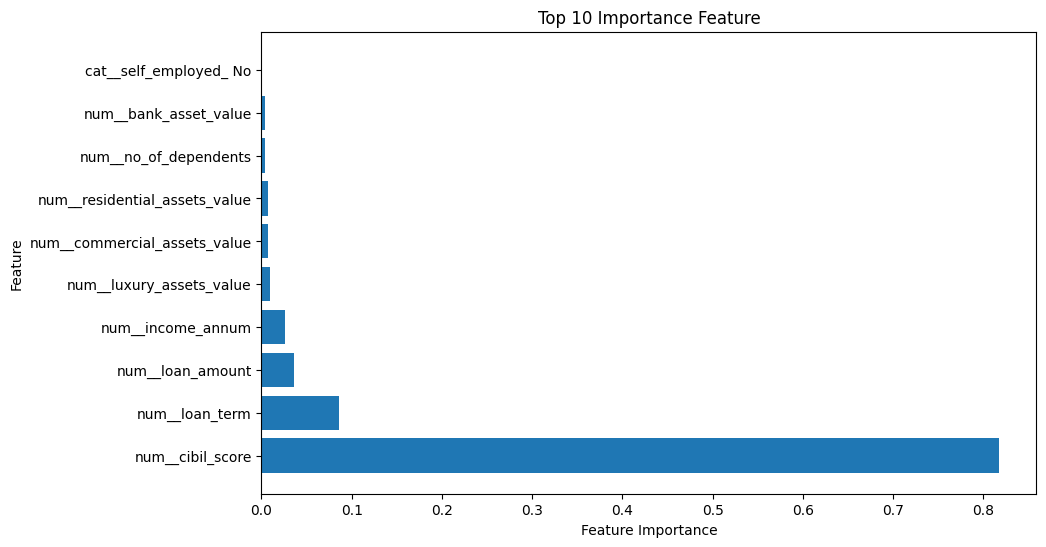

In [33]:
feature_importance = rf_clf_pipeline.named_steps['rf_cls'].feature_importances_
feature_names = rf_clf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importance_df = pd.DataFrame(
    {
        'Feature' : feature_names,
        'Importance' : feature_importance
    }
)

importance_df = importance_df.sort_values(by = 'Importance', ascending = False)
print("Top 10 Important Features : \n", importance_df.head(10))

plt.figure(figsize = (10, 6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Importance Feature")

# Stage 2 : Regression

In [34]:
df["loan_status"].unique()

array([' Approved', ' Rejected'], dtype=object)

In [35]:
df['loan_status'] = df["loan_status"].str.strip()
df['loan_status'].unique()

array(['Approved', 'Rejected'], dtype=object)

In [36]:
approved_df = df[df['loan_status'] == 'Approved'].copy()
approved_df.shape

(2656, 12)

In [37]:
approved_df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
6,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
8,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
10,4,Graduate,Yes,2900000,11200000,2,547,8100000,4700000,9500000,3100000,Approved
13,2,Graduate,Yes,9100000,31500000,14,679,10800000,16600000,20900000,5000000,Approved


In [38]:
reg_target = "loan_amount"
reg_df = approved_df.dropna(subset=[reg_target]).copy()

In [39]:
X_reg = reg_df.drop(columns=[reg_target])
y_reg = reg_df[reg_target]


In [40]:
cat_cols_reg = X_reg.select_dtypes(include = ['object', 'category']).columns.tolist()
num_cols_reg = X_reg.select_dtypes(include = [np.number]).columns.tolist()

In [41]:
print("Categorical Columns : ", cat_cols_reg)
print("Numerical Columns : ", num_cols_reg)

Categorical Columns :  ['education', 'self_employed', 'loan_status']
Numerical Columns :  ['no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [42]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size = 0.2, random_state = 42)
print("Train Size : ", Xr_train.shape)
print("Test Size : ", Xr_test.shape)

Train Size :  (2124, 11)
Test Size :  (532, 11)


In [43]:
reg_preprocessor = ColumnTransformer(transformers = [
    ('num', num_transformer, num_cols_reg),
    ('cat', cat_transformer, cat_cols_reg)
], remainder = 'drop')

# Fit Rf reg baseline Model

In [44]:
from sklearn.ensemble import RandomForestRegressor

In [45]:
rf_reg_pipeline = Pipeline(steps = [
    ('preprocessor', reg_preprocessor),
    ('rf_reg', RandomForestRegressor())
])

In [46]:
param_reg_grid = {
    'rf_reg__n_estimators' : [100,200,300,400],
    'rf_reg__max_depth' : [None, 4, 8, 10],
    'rf_reg__max_features' : ['sqrt', None],
    'rf_reg__min_samples_split' : [2,5,10]
}

In [47]:
rf_reg_pipeline.fit(Xr_train, yr_train)

,steps,"[('preprocessor', ...), ('rf_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
grid_reg = GridSearchCV(
    rf_reg_pipeline,
    param_reg_grid,
    cv = 5,
    scoring = "r2",
    n_jobs = -1
)
grid_reg.fit(Xr_train, yr_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'rf_reg__max_depth': [None, 4, ...], 'rf_reg__max_features': ['sqrt', None], 'rf_reg__min_samples_split': [2, 5, ...], 'rf_reg__n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [49]:
print("Best params (rf_reg) : ", grid_reg.best_params_)
best_reg = grid_reg.best_estimator_


Best params (rf_reg) :  {'rf_reg__max_depth': 4, 'rf_reg__max_features': None, 'rf_reg__min_samples_split': 10, 'rf_reg__n_estimators': 300}


In [50]:
grid_reg.best_score_

np.float64(0.8671037456122658)

# Regression Validation

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
rf_reg_pipeline = Pipeline(steps = [
    ('preprocessor', reg_preprocessor),
    ('rf_reg', RandomForestRegressor(
        n_estimators = 100,
        max_depth = 4,
        max_features = None,
        min_samples_split = 2
    ))
])

rf_reg_pipeline.fit(Xr_train, yr_train)
yr_pred = rf_reg_pipeline.predict(Xr_test)
print("MSE : ", mean_squared_error(yr_test, yr_pred))
print("MAE : ",  mean_absolute_error(yr_test, yr_pred))
print("R2 : ",  r2_score(yr_test, yr_pred))

MSE :  10834854228090.44
MAE :  2478629.2442471962
R2 :  0.8739424769230455


# Checking Feature Importance

Top 10 Important Features : 
                           Feature  Importance
1               num__income_annum    0.990845
3                num__cibil_score    0.002710
5    num__commercial_assets_value    0.001850
2                  num__loan_term    0.001693
6        num__luxury_assets_value    0.001436
4   num__residential_assets_value    0.000763
7           num__bank_asset_value    0.000621
0           num__no_of_dependents    0.000055
10         cat__self_employed_ No    0.000026
8        cat__education_ Graduate    0.000000


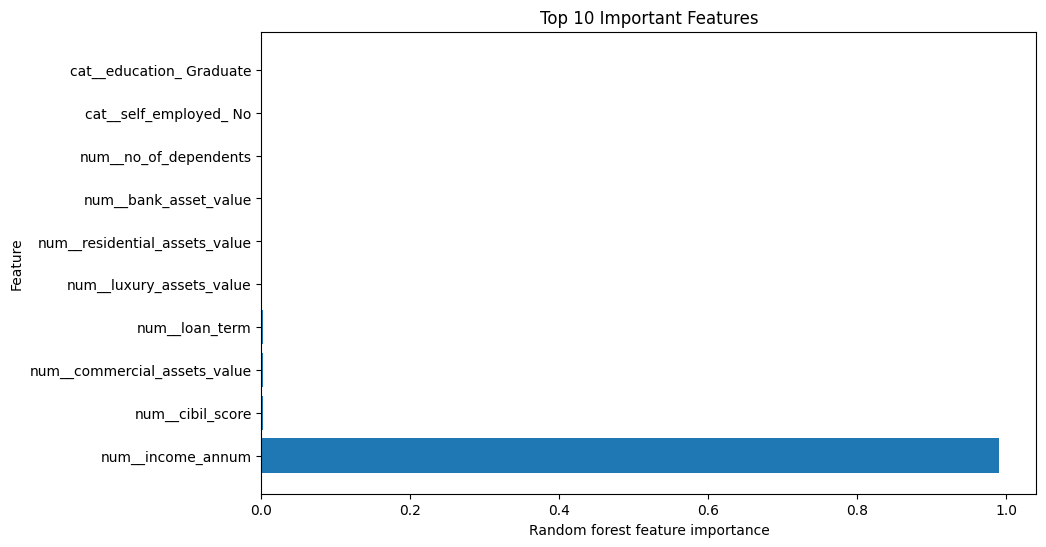

In [53]:
feature_importance = rf_reg_pipeline.named_steps['rf_reg'].feature_importances_
preprocessor = rf_reg_pipeline.named_steps['preprocessor']
features = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature" : features,
    "Importance" : feature_importance
})

importance_df = importance_df.sort_values(by = "Importance", ascending = False)

print("Top 10 Important Features : \n", importance_df.head(10))

plt.figure(figsize = (10, 6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel("Random forest feature importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.show()

# Save Artifacts & Combine Them in a Prediction function

In [54]:
import joblib

In [61]:
joblib.dump(rf_clf_pipeline, "../models/stage_1_rf_classifier_pipeline.pkl")
joblib.dump(rf_reg_pipeline, "../models/stage_2_rf_regression_pipeline.pkl")

['../models/stage_2_rf_regression_pipeline.pkl']

# Prediction Function


In [62]:
clf = joblib.load("../models/stage_1_rf_classifier_pipeline.pkl")
reg = joblib.load("../models/stage_2_rf_regression_pipeline.pkl")

In [63]:
def two_stage_predict(applicant_df):
    out = {}

    #stage 1
    approve = clf.predict(applicant_df)[0]
    out['loan_status'] = int(approve)

    if approve == 1:
        #stage 2
        applicant_df['loan_status'] = approve
        pred_loan_amount = reg.predict(applicant_df)[0]
        out['regression_prediction'] = float(pred_loan_amount)
    else:
        print("Not Approved")
    return out        


In [64]:
example_row = X_test.iloc[[0]]
print("Example row : \n")
display(example_row)

Example row : 



,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
2856,3,Not Graduate,Yes,8300000,31400000,6,674,1000000,1600000,17200000,6100000


In [ ]:
example_row.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 2856 to 2856
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          1 non-null      int64 
 1   education                 1 non-null      object
 2   self_employed             1 non-null      object
 3   income_annum              1 non-null      int64 
 4   loan_amount               1 non-null      int64 
 5   loan_term                 1 non-null      int64 
 6   cibil_score               1 non-null      int64 
 7   residential_assets_value  1 non-null      int64 
 8   commercial_assets_value   1 non-null      int64 
 9   luxury_assets_value       1 non-null      int64 
 10  bank_asset_value          1 non-null      int64 
dtypes: int64(9), object(2)
memory usage: 96.0+ bytes


In [65]:
print(reg.feature_names_in_)

['no_of_dependents' 'education' 'self_employed' 'income_annum' 'loan_term'
 'cibil_score' 'residential_assets_value' 'commercial_assets_value'
 'luxury_assets_value' 'bank_asset_value' 'loan_status']


In [66]:
print(clf.feature_names_in_)

['no_of_dependents' 'education' 'self_employed' 'income_annum'
 'loan_amount' 'loan_term' 'cibil_score' 'residential_assets_value'
 'commercial_assets_value' 'luxury_assets_value' 'bank_asset_value']


In [67]:
two_stage_predict(example_row)

C:\Users\hp\AppData\Local\Temp\ipykernel_41884\3536531173.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  applicant_df['loan_status'] = approve


{'loan_status': 1, 'regression_prediction': 24994197.74457931}

In [74]:
sample = pd.DataFrame([{
    'no_of_dependents' : 1,
    'education' : 'Graduate',
    'self_employed' : 'No', 
    'income_annum' : 1200000,
    'loan_amount' : 30000,
    'loan_term' : 12, 
    'cibil_score' : 800, 
    'residential_assets_value' : 2000000,
    'commercial_assets_value' : 2000000, 
    'luxury_assets_value' : 0, 
    'bank_asset_value' : 55000
}])
sample

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1,Graduate,No,1200000,30000,12,800,2000000,2000000,0,55000


In [75]:
two_stage_predict(sample)

{'loan_status': 1, 'regression_prediction': 3667890.5442305966}

In [78]:
clf_proba = clf.predict_proba(sample)
clf_proba

array([[0.08, 0.92]])

In [79]:
clf_proba.shape

(1, 2)

In [80]:
clf_proba[0][1]

np.float64(0.92)